In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [3]:
train = datasets.MNIST('../data', train=True, 
                       #download=True, 
                       transform=transforms.Compose([transforms.ToTensor()]))
test = datasets.MNIST('../data', train=False, 
                      transform=transforms.Compose([transforms.ToTensor()]))
print(train, test)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           ) Dataset MNIST
    Number of datapoints: 10000
    Root location: ../data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
           )


In [4]:
X = train.data.float() / 255
X = X.reshape(X.shape[0], -1)
y = train.targets
print(X.shape, y.shape)

torch.Size([60000, 784]) torch.Size([60000])


In [5]:
input_size = X.shape[-1]
output_size = int(max(y)) + 1
print(input_size, output_size)

784 10


In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)
X_test, y_test = test.data.float() / 255, test.targets
X_test = X_test.reshape(X_test.shape[0], -1)
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

torch.Size([48000, 784]) torch.Size([12000, 784]) torch.Size([10000, 784]) torch.Size([48000]) torch.Size([12000]) torch.Size([10000])


In [7]:
lowest_loss = np.inf
best_model = None
early_stop = 100
lowest_epoch = np.inf

In [8]:
n_epochs = 5000
batch_size = 512
learning_rate = 1e-4
print_interval = 100

In [9]:
class Block(nn.Module):
    def __init__(self, input_size, output_size, use_batch_norm=True, dropout_p=0.3):
        self.input_size = input_size
        self.output_size = output_size
        self.use_batch_norm = use_batch_norm
        self.dropout_p = dropout_p

        super().__init__()

        def get_regularizer(use_batch_norm, size):
            return nn.BatchNorm1d(size) if use_batch_norm else nn.Dropout(dropout_p)
        
        self.block = nn.Sequential(
            nn.Linear(input_size, output_size),
            nn.LeakyReLU(),
            get_regularizer(use_batch_norm, output_size)
        )
    
    def forward(self, X):
        y = self.block(X)
        return y

In [10]:
class MyModel(nn.Module):
    def __init__(self, input_size, output_size, n_layers=5, use_batch_norm=True, dropout_p=0.3):
        super().__init__()

        all_sizes = np.linspace(input_size, output_size, n_layers+2).astype('int')

        blocks = []
        for i in range(len(all_sizes)-2):
            blocks += [Block(all_sizes[i], all_sizes[i+1], use_batch_norm, dropout_p)]
        
        self.layers = nn.Sequential(
            *blocks,
            nn.Linear(all_sizes[-2], all_sizes[-1]),
            nn.LogSoftmax(dim=-1)
        )
    
    def forward(self, X):
        y = self.layers(X)
        return y

In [11]:
model = MyModel(input_size, output_size, use_batch_norm=True)
model = model.to(device)
print(model)

MyModel(
  (layers): Sequential(
    (0): Block(
      (block): Sequential(
        (0): Linear(in_features=784, out_features=655, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(655, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): Block(
      (block): Sequential(
        (0): Linear(in_features=655, out_features=526, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(526, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): Block(
      (block): Sequential(
        (0): Linear(in_features=526, out_features=397, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(397, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (3): Block(
      (block): Sequential(
        (0): Linear(in_features=397, out_features=268, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(268, e

In [12]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
crit = nn.NLLLoss()

In [13]:
train_history, valid_history = [], []

for i in range(n_epochs):
    model.train()

    indices = torch.randperm(X_train.shape[0])
    X_ = torch.index_select(X_train, dim=0, index=indices).to(device)
    y_ = torch.index_select(y_train, dim=0, index=indices).to(device)

    X_ = X_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    train_loss = 0
    y_hat = []

    for X_i, y_i in zip(X_, y_):
        y_hat_i = model(X_i)
        loss = crit(y_hat_i, y_i.squeeze())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += float(loss.detach())
    
    train_loss = train_loss / len(X_)

    model.eval()
    with torch.no_grad():
        X_ = X_val.to(device).split(batch_size, dim=0)
        y_ = y_val.to(device).split(batch_size, dim=0)

        valid_loss = 0

        for X_i, y_i in zip(X_, y_):
            y_hat_i = model(X_i)
            loss = crit(y_hat_i, y_i.squeeze())

            valid_loss += float(loss.detach())

            y_hat += [y_hat_i]
        
        valid_loss = valid_loss / len(X_)
    
    train_history += [train_loss]
    valid_history += [valid_loss]

    if (i + 1) % print_interval == 0:
        print(f'Epoch {i + 1}: train loss={train_loss:.4f}, valid loss={valid_loss:.4f}, lowest loss={lowest_loss:.4f}')
    
    if valid_loss < lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = i

        best_model = deepcopy(model.state_dict())
    else:
        if early_stop > 0 and lowest_epoch + early_stop < i + 1:
            print(f'There is no improvement during last {early_stop} epochs.')
            break

print(f'The best validation loss from epoch {lowest_epoch + 1}: {lowest_loss:.4f}')

model.load_state_dict(best_model)

Epoch 100: train loss=0.0001, valid loss=0.0708, lowest loss=0.0654
There is no improvement during last 100 epochs.
The best validation loss from epoch 76: 0.0654


<All keys matched successfully>

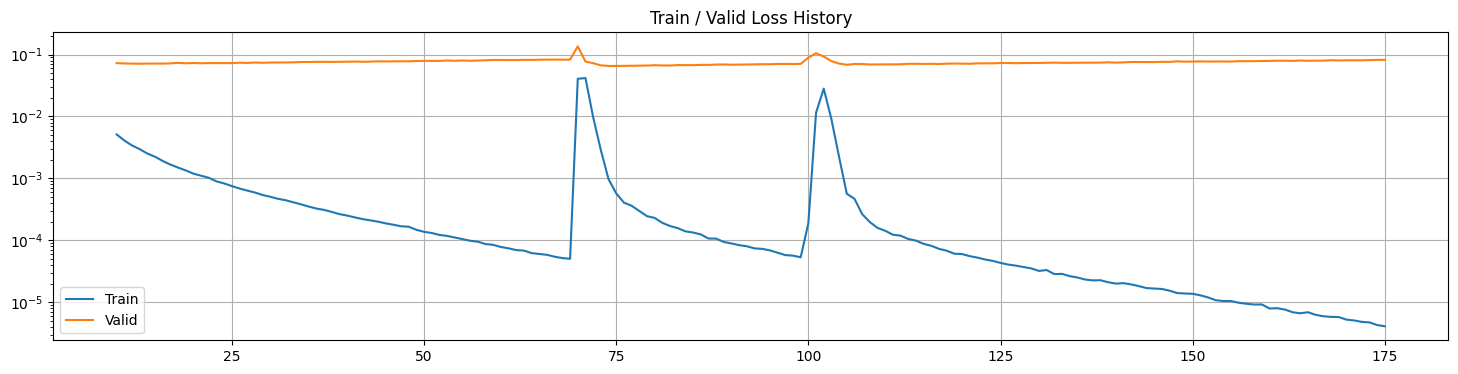

In [14]:
plot_from = 10

fig, ax = plt.subplots(1, 1, figsize=(18, 4))
plt.title('Train / Valid Loss History')
ax.plot(range(plot_from, len(train_history)), train_history[plot_from:],
         range(plot_from, len(valid_history)), valid_history[plot_from:])
plt.grid(True)
plt.yscale('log')
plt.legend(['Train', 'Valid'])
plt.show()

In [15]:
test_loss = 0
y_hat = []

model.eval()
with torch.no_grad():
    X_ = X_test.to(device).split(batch_size, dim=0)
    y_ = y_test.to(device).split(batch_size, dim=0)

    for X_i, y_i in zip(X_, y_):
        y_hat_i = model(X_i)
        loss = crit(y_hat_i, y_i.squeeze())

        test_loss += float(loss.detach())

        y_hat += [y_hat_i]
    
    test_loss = test_loss / len(X_)

y_hat = torch.concat(y_hat, dim=0)

In [16]:
sorted_history = sorted(zip(train_history, valid_history), key=lambda x: x[1])

print(f'Train loss: {sorted_history[0][0]:.4f}')
print(f'Valid loss: {sorted_history[0][1]:.4f}')
print(f'Test loss: {test_loss:.4f}')

Train loss: 0.0006
Valid loss: 0.0654
Test loss: 0.0701


In [17]:
correct_cnt = (y_test.squeeze() == torch.argmax(y_hat.to('cpu'), dim=-1)).sum()
total_cnt = y_test.shape[0]

print(f'Test Accuracy: {correct_cnt / total_cnt:.4f}')

Test Accuracy: 0.9824


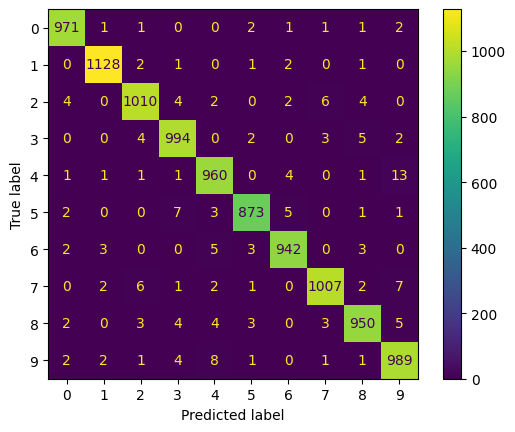

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test.squeeze(), torch.argmax(y_hat.to('cpu'), dim=-1))

In [19]:
del model
torch.cuda.empty_cache()